# Krill catch data formating

## Info on these data
We obtained the non-aggregated "C1 data" from the CCAMLR secretariat. These data gather the krill catch survey from 1988 to 2023. Data from 2006 onward are not aggregated, and before most of them have been resubmited at a haul-by-haul level. However, some of them are in an aggregated format : on 1°x0.5° long-lat rectangle and either 10-days or monthly temporal resolution. 

Non-aggregated data means that we have the green weight of krill from each haul, together witht the date and time and localisation to the tenth of degree of both the start and the end of the fishing period. 

All Members States agreed to deliver their data (i.e. the fishing data of the fishing vessel under their pavillon) for this study. As they are not publicly available, these data are not shared in the repository.

## Method for formating the data

### Temporal aggregation
We aggregate data at the fishing season level : a CCAMLR fishing season goes from 1rst of December to 30th of November of the next year. 
This allows to have a temporal serie of the catches and see how the spatial distribution evolves with time.

*Then we further aggregate the yearly data over three vast period :*
- 1988 -2000
- 2001 - 2010
- 2011 - 2023

These data are used for the spatial overlap analyses.

### Spatial aggregation

Some data are already in a aggregated format of 1°x0.5° long-lat rectangles. 

First we can further aggregate these data on a 2°x2° cells to match the spatial resolution of the sequestration time.

Most of the data are not aggregated, thus we aggregated them on a 1°x0.5° rectangles as the other data, and then to the 2°x2° "harmonized" resolution. 

In [145]:
# import libraries (ok sous base anaconda)
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import numpy as np
import pandas as pd
import scipy
import math
import datetime

In [73]:
# for pltting maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [74]:
# To be change with local directory of the data
import os
os.chdir('C:/Users/anael/Documents/PhD/4_krill_fisheries_Carbon_seq_time/CCAMLR_data_request/data_extract_648_2023-10-12') # put the local path : not open data, so not available in the git hub repo
C1_648 = pd.read_csv('C1_648.csv')

C:\Users\anael\AppData\Local\Temp\ipykernel_19020\3257860395.py:4: DtypeWarning: Columns (8,16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  C1_648 = pd.read_csv('C1_648.csv')


In [75]:
C1_648.columns

Index(['c1_id', 'obs_haul_id', 'obs_logbook_id', 'obs_haul_number',
       'haul_number', 'fishing_purpose_code', 'season_ccamlr',
       'target_species', 'asd_code', 'trawl_technique', 'catchperiod_code',
       'vessel_count', 'haul_count', 'trawling_days', 'hours_fishing',
       'date_catchperiod_start', 'datetime_set_start', 'datetime_set_end',
       'datetime_haul_start', 'datetime_haul_end', 'datetime_timezone',
       'depth_gear_set_end_m', 'depth_gear_haul_start_m',
       'depth_bottom_set_end_m', 'depth_bottom_haul_start_m',
       'latitude_set_end', 'longitude_set_end', 'latitude_haul_start',
       'longitude_haul_start', 'latitude_fsr', 'longitude_fsr', 'latitude',
       'longitude', 'notes', 'krill_greenweight_kg', 'trawl_duration_depth_h',
       'trawl_duration_total_h'],
      dtype='object')

In [76]:
# add the month as a column to filter by month 
C1_648['date_catchperiod_start'] = pd.to_datetime(C1_648['date_catchperiod_start'])
C1_648['month_catchperiod_start'] = C1_648['date_catchperiod_start'].dt.month

In [77]:
# separate the data that are aggregated 
# They are 3 levels of aggragation : day, 10gays, months.
# "10-days" and "month" are aggergated in the 1°x0.5° rectangles but "days" are not

aggragation_level = ['10_day', 'month']

agg_data = C1_648.loc[C1_648['catchperiod_code'].isin(aggragation_level)] # we can keep this part of the dataset (the lat - long fsr are already assigned)
agg_data.shape # (2232, 37)

(2232, 38)

#### "Day" aggregated data
For the data aggregarted by days, the coordinates lat-long avialable corresponds to the latitude of the end of the fishing haul. 
We aggregate these coordinates over the 1°x0.5° rectangles by rounding the coordinates to the nearest rectable center point.

In [78]:
# isolate the 'day agregated data'
day_data = C1_648.loc[C1_648['catchperiod_code'] == 'day']
day_data.shape # (4095, 37)

(4095, 38)

In [79]:
# round the coordinated of the data on a day aggregation to the nearest midpoint of the 1°x0.25° rectangle:
# to do thise we have to round to the nearst 1/4th of degree for latitude and to the nearrest 1/2 degree for longitude

# we take the integer part and then substract 0.5°
def round_longitude(x):
    if x<0 : 
        return(np.trunc(x) - 0.5)
    if x>=0 :
        return(np.trunc(x) + 0.5)

# for latitude we first round to nearest half and then substract 0.25° (we only have negative values of the latitude)
def round_latitude(y):
    return((np.ceil(y*2)/2) - 0.25)

In [80]:
day_data['longitude_fsr'] = day_data['longitude'].apply(round_longitude)
day_data['latitude_fsr'] = day_data['latitude'].apply(round_latitude)
day_data

C:\Users\anael\AppData\Local\Temp\ipykernel_19020\2974597215.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_data['longitude_fsr'] = day_data['longitude'].apply(round_longitude)
C:\Users\anael\AppData\Local\Temp\ipykernel_19020\2974597215.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_data['latitude_fsr'] = day_data['latitude'].apply(round_latitude)


,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start
183,1523,NaN,NaN,NaN,1523.0,C,1989,KRI,481,T,...,NaN,-62.25,-61.5,-62.283333,-61.000000,NaN,5000.0,NaN,NaN,1
184,1524,NaN,NaN,NaN,1524.0,C,1989,KRI,481,T,...,NaN,-62.25,-61.5,-62.200000,-61.000000,NaN,7000.0,NaN,NaN,1
185,1525,NaN,NaN,NaN,1525.0,C,1989,KRI,481,T,...,NaN,-62.25,-60.5,-62.283333,-60.000000,NaN,4000.0,NaN,NaN,1
186,1526,NaN,NaN,NaN,1526.0,C,1989,KRI,481,T,...,NaN,-62.25,-60.5,-62.333333,-60.000000,NaN,10000.0,NaN,NaN,1
187,1527,NaN,NaN,NaN,1527.0,C,1989,KRI,481,T,...,NaN,-62.25,-61.5,-62.266667,-61.000000,NaN,10000.0,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130110,242177,NaN,NaN,NaN,160.0,C,2005,KRI,483,T,...,NaN,-53.75,-36.5,-53.800000,-36.183333,Summary data,97855.0,NaN,NaN,8
130111,242178,NaN,NaN,NaN,161.0,C,2005,KRI,483,T,...,NaN,-53.75,-36.5,-53.783333,-36.133333,Summary data,9576.0,NaN,NaN,8
130112,242179,NaN,NaN,NaN,162.0,C,2005,KRI,483,T,...,NaN,-53.75,-36.5,-53.783333,-36.133333,Summary data,97974.0,NaN,NaN,8
130113,242180,NaN,NaN,NaN,163.0,C,2005,KRI,483,T,...,NaN,-53.75,-36.5,-53.816667,-36.166667,Summary data,97735.0,NaN,NaN,8


In [81]:
# merge the completed 'day data' with the rest of the aggregated data
agg_data = pd.concat([agg_data, day_data])

agg_data.shape # (6327, 37) OK

(6327, 38)

## No aggregation data

For these data we have the coordinates of the start and the end of each trawl tow. For each haul (row in the dataset), we have the krill greenweight. 

We face different cases in order to aggregate these data on the spatial grid (i.e. the 1°x0.5° long-lat rectangles).

- Some data have missing values for the latitude and longitude of the starting point
We first check for these cases and put them aside to be treated like the 'day' aggregated data : we round the known coordinates (the end point of the tow) to the nearest cell center point.

- In most of the cases the start and end coordinates belong to the same cells (1°x0.5° rectangle)
When the start and end coordinates belong to the same cell, the latitude-fsr adnd longitude-fsr are filled the coordinates of the center point of the corresponding cell and the whole krill catch biomass is assigned to this cell.

- In some cases, the trawl tow is straddling on two cells
When the start and end coordinates do not belong to the same cell, two rows are created with the latitude-fsr and longitude-fsr of the two cells and the extracted biomass is assigned to each one proportionnaly to the length of the tow belonging to each cell (Here we hypothesis than the tows are in straight lines).

In [82]:
# extract the not aggregated part of the data set
# note that fsr coordinatesare empty for these rows
unagg_data = C1_648.loc[C1_648['catchperiod_code'] == 'haul']
print(unagg_data.shape) # 397205 rows
unagg_data

(397205, 38)


,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start
4766,26529,NaN,NaN,NaN,1.0,C,1998,KRI,481,T,...,NaN,NaN,NaN,-60.78000,-56.08000,NaN,7260.000,0.416667,0.750000,12
4767,26530,NaN,NaN,NaN,2.0,C,1998,KRI,481,T,...,NaN,NaN,NaN,-60.80000,-56.08000,NaN,7920.000,0.750000,1.083333,12
4768,26531,NaN,NaN,NaN,4.0,C,1998,KRI,481,T,...,NaN,NaN,NaN,-60.85000,-56.10000,NaN,4692.000,1.583333,1.900000,12
4769,26532,NaN,NaN,NaN,5.0,C,1998,KRI,481,T,...,NaN,NaN,NaN,-60.78000,-56.05000,NaN,5896.000,2.583333,2.966667,12
4770,26533,NaN,NaN,NaN,6.0,C,1998,KRI,481,T,...,NaN,NaN,NaN,-60.98000,-56.20000,NaN,88.000,1.500000,1.783333,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403527,537073,NaN,NaN,NaN,4677.0,C,2023,KRI,483,C,...,-36.07833,NaN,NaN,-53.87167,-36.02333,NaN,8643.049,2.000000,2.000000,9
403528,537076,NaN,NaN,NaN,4680.0,C,2023,KRI,483,C,...,-36.22000,NaN,NaN,-53.82167,-36.15333,NaN,6630.144,2.000000,2.000000,9
403529,537077,NaN,NaN,NaN,4681.0,C,2023,KRI,483,C,...,-36.22000,NaN,NaN,-53.82167,-36.15333,NaN,6630.144,2.000000,2.000000,9
403530,537078,NaN,NaN,NaN,4682.0,C,2023,KRI,483,C,...,-36.14833,NaN,NaN,-53.79000,-36.22000,NaN,7514.163,2.000000,2.000000,9


### Extract the rows where start coordinates are not available (only the end point is known)

In [83]:
# check the NAN : some of the rows have a nan for the lat and long haul start 
# when only the set end lat and long are available, the data are treated like the 'day' aggregated data
# when start and end lat and long are available, then the procedure describe above is apply to assigned the catched biomass to the cells

# seclect the part of the dataset where lat-long of the start is non available:
unagg_data_NAN_start = unagg_data.loc[unagg_data['latitude_haul_start'].isna()]
unagg_data_NAN_start # 101677 rows

# here we remove the rows with these missing values - then this dataframe is used
unagg_data_noNAN = unagg_data.loc[unagg_data['latitude_haul_start'].notna()]
unagg_data_noNAN # 295528 rows

# 101677 + 295528 = 397205 (=nb of rows of unagg_data) OK

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start
5699,30751,NaN,NaN,NaN,9.0,C,1999,KRI,481,T,...,-58.72000,NaN,NaN,-62.65000,-58.75000,NaN,8000.000,0.750000,1.500000,8
5700,30752,NaN,NaN,NaN,10.0,C,1999,KRI,481,T,...,-58.35000,NaN,NaN,-62.72000,-58.37000,NaN,8000.000,1.250000,4.333333,8
5701,30753,NaN,NaN,NaN,11.0,C,1999,KRI,481,T,...,-58.53000,NaN,NaN,-62.72000,-58.50000,NaN,15000.000,1.083333,1.916667,8
5702,30754,NaN,NaN,NaN,12.0,C,1999,KRI,481,T,...,-58.58000,NaN,NaN,-62.67000,-58.53000,NaN,20000.000,1.333333,2.000000,8
5703,30755,NaN,NaN,NaN,13.0,C,1999,KRI,481,T,...,-58.48000,NaN,NaN,-62.68000,-58.55000,NaN,6000.000,1.366667,2.083333,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403527,537073,NaN,NaN,NaN,4677.0,C,2023,KRI,483,C,...,-36.07833,NaN,NaN,-53.87167,-36.02333,NaN,8643.049,2.000000,2.000000,9
403528,537076,NaN,NaN,NaN,4680.0,C,2023,KRI,483,C,...,-36.22000,NaN,NaN,-53.82167,-36.15333,NaN,6630.144,2.000000,2.000000,9
403529,537077,NaN,NaN,NaN,4681.0,C,2023,KRI,483,C,...,-36.22000,NaN,NaN,-53.82167,-36.15333,NaN,6630.144,2.000000,2.000000,9
403530,537078,NaN,NaN,NaN,4682.0,C,2023,KRI,483,C,...,-36.14833,NaN,NaN,-53.79000,-36.22000,NaN,7514.163,2.000000,2.000000,9


In [84]:
## Assing the "latitude/longitude_fsr" with the same procedure than with 'day' aggregated data
unagg_data_NAN_start['longitude_fsr'] = unagg_data_NAN_start['longitude'].apply(round_longitude)
unagg_data_NAN_start['latitude_fsr'] = unagg_data_NAN_start['latitude'].apply(round_latitude)
unagg_data_NAN_start # 101677 rows × 37 columns

C:\Users\anael\AppData\Local\Temp\ipykernel_19020\1790933794.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unagg_data_NAN_start['longitude_fsr'] = unagg_data_NAN_start['longitude'].apply(round_longitude)
C:\Users\anael\AppData\Local\Temp\ipykernel_19020\1790933794.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unagg_data_NAN_start['latitude_fsr'] = unagg_data_NAN_start['latitude'].apply(round_latitude)


,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start
4766,26529,NaN,NaN,NaN,1.0,C,1998,KRI,481,T,...,NaN,-60.75,-56.5,-60.780000,-56.080000,NaN,7260.0,0.416667,0.750000,12
4767,26530,NaN,NaN,NaN,2.0,C,1998,KRI,481,T,...,NaN,-60.75,-56.5,-60.800000,-56.080000,NaN,7920.0,0.750000,1.083333,12
4768,26531,NaN,NaN,NaN,4.0,C,1998,KRI,481,T,...,NaN,-60.75,-56.5,-60.850000,-56.100000,NaN,4692.0,1.583333,1.900000,12
4769,26532,NaN,NaN,NaN,5.0,C,1998,KRI,481,T,...,NaN,-60.75,-56.5,-60.780000,-56.050000,NaN,5896.0,2.583333,2.966667,12
4770,26533,NaN,NaN,NaN,6.0,C,1998,KRI,481,T,...,NaN,-60.75,-56.5,-60.980000,-56.200000,NaN,88.0,1.500000,1.783333,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118948,225411,NaN,NaN,NaN,42.0,C,2005,KRI,481,T,...,NaN,-62.25,-59.5,-62.150000,-59.916667,NaN,10000.0,1.000000,1.500000,5
118949,225412,NaN,NaN,NaN,43.0,C,2005,KRI,481,T,...,NaN,-62.25,-59.5,-62.150000,-59.950000,NaN,6000.0,1.000000,1.500000,5
118950,225413,NaN,NaN,NaN,44.0,C,2005,KRI,481,T,...,NaN,-62.25,-59.5,-62.166667,-59.900000,NaN,2000.0,1.000000,1.583333,5
118951,225414,NaN,NaN,NaN,45.0,C,2005,KRI,481,T,...,NaN,-62.25,-59.5,-62.150000,-59.866667,NaN,5000.0,1.000000,1.583333,5


In [85]:
# merge these data with the aggregated data 
agg_data = pd.concat([agg_data, unagg_data_NAN_start])
agg_data.shape # (108004, 37)

(108004, 38)

### Applied conditions on the start end end latitude and longitude to distinguish the tows straddling on two different cells

Formalisation of the conditions to separate the two different cases explained above:

The whole biomass is attributed to the cell of coordinates longitude x and latitude y IF:

- the longitude of the start and the longitude of the end is on the same cell => **the integer part(long_start) == the integer part(long_end)**


AND 


- the latitude of the start and the latitude of the end is on the same cell => **the integer part(lat_start) == the integer part(lat_start)** AND **the decimal part(lat_start) AND the decimal part(lat_end) >= 0.5 OR both < 0.5**


In [86]:
# condition on longitude
condition_long = np.trunc(unagg_data_noNAN.longitude_haul_start) == np.trunc(unagg_data_noNAN.longitude_set_end)
condition_long

5699      True
5700      True
5701      True
5702      True
5703      True
          ... 
403527    True
403528    True
403529    True
403530    True
403531    True
Length: 295528, dtype: bool

In [87]:
#conditions on latitude
condition_lat1 = (np.trunc(unagg_data_noNAN.latitude_haul_start) == np.trunc(unagg_data_noNAN.latitude_set_end)) 
condition_lat1

5699      True
5700      True
5701      True
5702      True
5703      True
          ... 
403527    True
403528    True
403529    True
403530    True
403531    True
Length: 295528, dtype: bool

In [88]:
condition_lat2 = ((np.trunc(unagg_data_noNAN.latitude_haul_start) - unagg_data_noNAN.latitude_haul_start) < 0.5) & ((np.trunc(unagg_data_noNAN.latitude_set_end) - unagg_data_noNAN.latitude_set_end) < 0.5 )
condition_lat2

5699      False
5700      False
5701      False
5702      False
5703      False
          ...  
403527    False
403528    False
403529    False
403530    False
403531    False
Length: 295528, dtype: bool

In [89]:
condition_lat3 = ((np.trunc(unagg_data_noNAN.latitude_haul_start) - unagg_data_noNAN.latitude_haul_start) >= 0.5) & ((np.trunc(unagg_data_noNAN.latitude_set_end) - unagg_data_noNAN.latitude_set_end)>= 0.5)
condition_lat3

5699      True
5700      True
5701      True
5702      True
5703      True
          ... 
403527    True
403528    True
403529    True
403530    True
403531    True
Length: 295528, dtype: bool

In [90]:
condition_lat = condition_lat1 & condition_lat2 | condition_lat3
condition_lat

5699      True
5700      True
5701      True
5702      True
5703      True
          ... 
403527    True
403528    True
403529    True
403530    True
403531    True
Length: 295528, dtype: bool

### test condition par condition
A short test condition by condition to check how many rows are removed from each conditions.

In [91]:
#subset of the data where condition on longitude is verified
unagg_data_cond_long = unagg_data_noNAN.loc[condition_long]
unagg_data_cond_long # 280739 (but 295528 in unagg_data_noNAN => -14789)

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start
5699,30751,NaN,NaN,NaN,9.0,C,1999,KRI,481,T,...,-58.72000,NaN,NaN,-62.65000,-58.75000,NaN,8000.000,0.750000,1.500000,8
5700,30752,NaN,NaN,NaN,10.0,C,1999,KRI,481,T,...,-58.35000,NaN,NaN,-62.72000,-58.37000,NaN,8000.000,1.250000,4.333333,8
5701,30753,NaN,NaN,NaN,11.0,C,1999,KRI,481,T,...,-58.53000,NaN,NaN,-62.72000,-58.50000,NaN,15000.000,1.083333,1.916667,8
5702,30754,NaN,NaN,NaN,12.0,C,1999,KRI,481,T,...,-58.58000,NaN,NaN,-62.67000,-58.53000,NaN,20000.000,1.333333,2.000000,8
5703,30755,NaN,NaN,NaN,13.0,C,1999,KRI,481,T,...,-58.48000,NaN,NaN,-62.68000,-58.55000,NaN,6000.000,1.366667,2.083333,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403527,537073,NaN,NaN,NaN,4677.0,C,2023,KRI,483,C,...,-36.07833,NaN,NaN,-53.87167,-36.02333,NaN,8643.049,2.000000,2.000000,9
403528,537076,NaN,NaN,NaN,4680.0,C,2023,KRI,483,C,...,-36.22000,NaN,NaN,-53.82167,-36.15333,NaN,6630.144,2.000000,2.000000,9
403529,537077,NaN,NaN,NaN,4681.0,C,2023,KRI,483,C,...,-36.22000,NaN,NaN,-53.82167,-36.15333,NaN,6630.144,2.000000,2.000000,9
403530,537078,NaN,NaN,NaN,4682.0,C,2023,KRI,483,C,...,-36.14833,NaN,NaN,-53.79000,-36.22000,NaN,7514.163,2.000000,2.000000,9


In [92]:
#subset of the data where condition on latitude is verified
unagg_data_cond_lat = unagg_data_noNAN.loc[condition_lat]
unagg_data_cond_lat # 282625 ( -12903)

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start
5699,30751,NaN,NaN,NaN,9.0,C,1999,KRI,481,T,...,-58.72000,NaN,NaN,-62.65000,-58.75000,NaN,8000.000,0.750000,1.500000,8
5700,30752,NaN,NaN,NaN,10.0,C,1999,KRI,481,T,...,-58.35000,NaN,NaN,-62.72000,-58.37000,NaN,8000.000,1.250000,4.333333,8
5701,30753,NaN,NaN,NaN,11.0,C,1999,KRI,481,T,...,-58.53000,NaN,NaN,-62.72000,-58.50000,NaN,15000.000,1.083333,1.916667,8
5702,30754,NaN,NaN,NaN,12.0,C,1999,KRI,481,T,...,-58.58000,NaN,NaN,-62.67000,-58.53000,NaN,20000.000,1.333333,2.000000,8
5703,30755,NaN,NaN,NaN,13.0,C,1999,KRI,481,T,...,-58.48000,NaN,NaN,-62.68000,-58.55000,NaN,6000.000,1.366667,2.083333,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403527,537073,NaN,NaN,NaN,4677.0,C,2023,KRI,483,C,...,-36.07833,NaN,NaN,-53.87167,-36.02333,NaN,8643.049,2.000000,2.000000,9
403528,537076,NaN,NaN,NaN,4680.0,C,2023,KRI,483,C,...,-36.22000,NaN,NaN,-53.82167,-36.15333,NaN,6630.144,2.000000,2.000000,9
403529,537077,NaN,NaN,NaN,4681.0,C,2023,KRI,483,C,...,-36.22000,NaN,NaN,-53.82167,-36.15333,NaN,6630.144,2.000000,2.000000,9
403530,537078,NaN,NaN,NaN,4682.0,C,2023,KRI,483,C,...,-36.14833,NaN,NaN,-53.79000,-36.22000,NaN,7514.163,2.000000,2.000000,9


## Condition both on latitude and longitude

In [93]:
condition = condition_long & condition_lat
condition

5699      True
5700      True
5701      True
5702      True
5703      True
          ... 
403527    True
403528    True
403529    True
403530    True
403531    True
Length: 295528, dtype: bool

#### The subset that is respecting the conditon : no straddling

In [94]:
# create the subset of the data that is the data on haul basis where the entire tow is in the same cell
unagg_data_cond = unagg_data_noNAN.loc[condition]
unagg_data_cond # 268399  (-27129)

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start
5699,30751,NaN,NaN,NaN,9.0,C,1999,KRI,481,T,...,-58.72000,NaN,NaN,-62.65000,-58.75000,NaN,8000.000,0.750000,1.500000,8
5700,30752,NaN,NaN,NaN,10.0,C,1999,KRI,481,T,...,-58.35000,NaN,NaN,-62.72000,-58.37000,NaN,8000.000,1.250000,4.333333,8
5701,30753,NaN,NaN,NaN,11.0,C,1999,KRI,481,T,...,-58.53000,NaN,NaN,-62.72000,-58.50000,NaN,15000.000,1.083333,1.916667,8
5702,30754,NaN,NaN,NaN,12.0,C,1999,KRI,481,T,...,-58.58000,NaN,NaN,-62.67000,-58.53000,NaN,20000.000,1.333333,2.000000,8
5703,30755,NaN,NaN,NaN,13.0,C,1999,KRI,481,T,...,-58.48000,NaN,NaN,-62.68000,-58.55000,NaN,6000.000,1.366667,2.083333,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403527,537073,NaN,NaN,NaN,4677.0,C,2023,KRI,483,C,...,-36.07833,NaN,NaN,-53.87167,-36.02333,NaN,8643.049,2.000000,2.000000,9
403528,537076,NaN,NaN,NaN,4680.0,C,2023,KRI,483,C,...,-36.22000,NaN,NaN,-53.82167,-36.15333,NaN,6630.144,2.000000,2.000000,9
403529,537077,NaN,NaN,NaN,4681.0,C,2023,KRI,483,C,...,-36.22000,NaN,NaN,-53.82167,-36.15333,NaN,6630.144,2.000000,2.000000,9
403530,537078,NaN,NaN,NaN,4682.0,C,2023,KRI,483,C,...,-36.14833,NaN,NaN,-53.79000,-36.22000,NaN,7514.163,2.000000,2.000000,9


In [95]:
## For the unagg_data_cond
unagg_data_cond['longitude_fsr'] = unagg_data_cond['longitude'].apply(round_longitude)
unagg_data_cond['latitude_fsr'] = unagg_data_cond['latitude'].apply(round_latitude)
unagg_data_cond

C:\Users\anael\AppData\Local\Temp\ipykernel_19020\2383067816.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unagg_data_cond['longitude_fsr'] = unagg_data_cond['longitude'].apply(round_longitude)
C:\Users\anael\AppData\Local\Temp\ipykernel_19020\2383067816.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unagg_data_cond['latitude_fsr'] = unagg_data_cond['latitude'].apply(round_latitude)


,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start
5699,30751,NaN,NaN,NaN,9.0,C,1999,KRI,481,T,...,-58.72000,-62.75,-58.5,-62.65000,-58.75000,NaN,8000.000,0.750000,1.500000,8
5700,30752,NaN,NaN,NaN,10.0,C,1999,KRI,481,T,...,-58.35000,-62.75,-58.5,-62.72000,-58.37000,NaN,8000.000,1.250000,4.333333,8
5701,30753,NaN,NaN,NaN,11.0,C,1999,KRI,481,T,...,-58.53000,-62.75,-58.5,-62.72000,-58.50000,NaN,15000.000,1.083333,1.916667,8
5702,30754,NaN,NaN,NaN,12.0,C,1999,KRI,481,T,...,-58.58000,-62.75,-58.5,-62.67000,-58.53000,NaN,20000.000,1.333333,2.000000,8
5703,30755,NaN,NaN,NaN,13.0,C,1999,KRI,481,T,...,-58.48000,-62.75,-58.5,-62.68000,-58.55000,NaN,6000.000,1.366667,2.083333,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403527,537073,NaN,NaN,NaN,4677.0,C,2023,KRI,483,C,...,-36.07833,-53.75,-36.5,-53.87167,-36.02333,NaN,8643.049,2.000000,2.000000,9
403528,537076,NaN,NaN,NaN,4680.0,C,2023,KRI,483,C,...,-36.22000,-53.75,-36.5,-53.82167,-36.15333,NaN,6630.144,2.000000,2.000000,9
403529,537077,NaN,NaN,NaN,4681.0,C,2023,KRI,483,C,...,-36.22000,-53.75,-36.5,-53.82167,-36.15333,NaN,6630.144,2.000000,2.000000,9
403530,537078,NaN,NaN,NaN,4682.0,C,2023,KRI,483,C,...,-36.14833,-53.75,-36.5,-53.79000,-36.22000,NaN,7514.163,2.000000,2.000000,9


In [96]:
# concatenate witht the rest of the dataset 
agg_data = pd.concat([agg_data, unagg_data_cond])
agg_data.shape # (376403, 37)

(376403, 38)

#### The subset of the data that is not respecting the condition : straddling between cells

In [97]:
# create the subset of the dataset where the tows cross only the latitude border of a cell, only the longitude border of a cell or both
# use antijoin to have the subset of the data where the conditon is not verified
#separate the cases when the longitude border is crossed or latitude or both

outer_lat = unagg_data_noNAN.merge(unagg_data_cond_lat, how = 'outer', indicator = True)
crossing_lat = outer_lat[(outer_lat._merge == 'left_only')].drop('_merge', axis =1) # 12903 

outer_long = unagg_data_noNAN.merge(unagg_data_cond_long, how = 'outer', indicator = True)
crossing_long = outer_long[(outer_long._merge == 'left_only')].drop('_merge', axis =1) # 14789 

# crossing both lat and long borders
crossing_both = pd.merge(crossing_lat, crossing_long, how = 'inner') # 563

In [98]:
# removing the 'both' from the lat and long crossing to have the cases where ONLY the latitude or the longitude is crossed
outer = crossing_lat.merge(crossing_both, how='outer', indicator=True)
crossing_lat_only = outer[(outer._merge=='left_only')].drop('_merge', axis=1)
crossing_lat_only #12903-12340 = 563 OK

outer = crossing_long.merge(crossing_both, how='outer', indicator=True)
crossing_long_only = outer[(outer._merge=='left_only')].drop('_merge', axis=1)
crossing_long_only # 14789- 14226 = 563 OK

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start
0,30767,NaN,NaN,NaN,25.0,C,1999,KRI,481,T,...,-56.97000,NaN,NaN,-61.70000,-57.00000,NaN,3000.00,2.333333,3.000000,8
1,30768,NaN,NaN,NaN,26.0,C,1999,KRI,481,T,...,-56.97000,NaN,NaN,-61.67000,-57.12000,NaN,2000.00,0.500000,1.166667,8
2,30792,NaN,NaN,NaN,50.0,C,1999,KRI,481,T,...,-57.98000,NaN,NaN,-61.75000,-58.15000,NaN,15000.00,0.583333,1.666667,9
3,30894,NaN,NaN,NaN,152.0,C,1999,KRI,481,T,...,-58.03000,NaN,NaN,-61.63000,-57.97000,NaN,5000.00,1.583333,2.533333,9
4,30896,NaN,NaN,NaN,154.0,C,1999,KRI,481,T,...,-57.98000,NaN,NaN,-61.65000,-58.08000,NaN,4000.00,NaN,2.666667,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14784,537053,NaN,NaN,NaN,4657.0,C,2023,KRI,483,C,...,-36.02333,NaN,NaN,-53.85167,-35.99000,NaN,29944.82,2.000000,2.000000,9
14785,537060,NaN,NaN,NaN,4664.0,C,2023,KRI,483,C,...,-35.99500,NaN,NaN,-53.87667,-36.03667,NaN,16785.11,2.000000,2.000000,9
14786,537061,NaN,NaN,NaN,4665.0,C,2023,KRI,483,C,...,-35.99500,NaN,NaN,-53.87667,-36.03667,NaN,16785.11,2.000000,2.000000,9
14787,537062,NaN,NaN,NaN,4666.0,C,2023,KRI,483,C,...,-36.02000,NaN,NaN,-53.86167,-35.99500,NaN,33116.40,1.983333,1.983333,9


In [99]:
crossing_lat_only

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start
0,30777,NaN,NaN,NaN,35.0,C,1999,KRI,481,T,...,-57.23000,NaN,NaN,-61.93000,-57.22000,NaN,2000.000000,1.083333,2.016667,8
1,31336,NaN,NaN,NaN,158.0,C,1999,KRI,482,T,...,-46.32000,NaN,NaN,-60.48000,-46.27000,NaN,15000.000000,1.000000,1.583333,5
2,31355,NaN,NaN,NaN,177.0,C,1999,KRI,482,T,...,-46.37000,NaN,NaN,-60.50000,-46.37000,NaN,8000.000000,0.916667,1.416667,5
3,31379,NaN,NaN,NaN,201.0,C,1999,KRI,482,T,...,-46.48000,NaN,NaN,-60.45000,-46.40000,NaN,10000.000000,0.916667,1.583333,5
4,31380,NaN,NaN,NaN,202.0,C,1999,KRI,482,T,...,-46.50000,NaN,NaN,-60.58000,-46.50000,NaN,6000.000000,1.083333,1.666667,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12898,534660,347043.0,2413.0,1768.0,1768.0,C,2023,KRI,483,T,...,-35.61883,NaN,NaN,-53.99283,-35.64667,NaN,20518.570000,0.500000,0.916667,7
12899,534661,347044.0,2413.0,1769.0,1769.0,C,2023,KRI,483,T,...,-35.64083,NaN,NaN,-54.00617,-35.61700,NaN,21565.420000,0.500000,1.000000,7
12900,534664,347047.0,2413.0,1772.0,1772.0,C,2023,KRI,483,T,...,-35.61883,NaN,NaN,-53.99417,-35.62700,NaN,21565.420000,0.250000,0.666667,7
12901,536334,NaN,NaN,NaN,3790.0,C,2023,KRI,483,C,...,-36.53167,NaN,NaN,-53.49667,-36.45667,NaN,4.882888,2.000000,2.000000,8


#### Assigne the cells coordinates "fsr" and the krill biomass

- For the **tows thar are not straddling between cells ("unagg_data_cond" dataset)**, just assigned the cells coorindates at latitude-frs and longitude-fsr, rounding the latitude and longitude coordinates (end point of the tow) the nearest rectangles mid-point (same procedure as for day aggregated data).

- For the **straddling data**, created the same dataset with the latitude-fsr and longitude-fsr calculated from rounding either the start point or the end point of the tow. Then concatenate the datasets.

#### Subset when tows are straddling several cells

In [100]:
## For the straddling data on LATITUDE
# create 2 datasets where frs coordinates are one of the two cells that a tow crosses 
# then we can concatenate them (=> 1 row in the original dataset becomes two rows in the final one)

crossing_lat_s = crossing_lat_only.drop(columns=['longitude_fsr', 'latitude_fsr']) # with strating point 
crossing_lat_s['longitude_fsr'] = crossing_lat_s['longitude_haul_start'].apply(round_longitude)
crossing_lat_s['latitude_fsr'] = crossing_lat_s['latitude_haul_start'].apply(round_latitude)

crossing_lat_e = crossing_lat_only.drop(columns=['longitude_fsr', 'latitude_fsr']) # with ending point
crossing_lat_e['longitude_fsr'] = crossing_lat_e['longitude'].apply(round_longitude)
crossing_lat_e['latitude_fsr'] = crossing_lat_e['latitude'].apply(round_latitude)

In [101]:
crossing_lat_s

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,longitude_fsr,latitude_fsr
0,30777,NaN,NaN,NaN,35.0,C,1999,KRI,481,T,...,-57.23000,-61.93000,-57.22000,NaN,2000.000000,1.083333,2.016667,8,-57.5,-62.25
1,31336,NaN,NaN,NaN,158.0,C,1999,KRI,482,T,...,-46.32000,-60.48000,-46.27000,NaN,15000.000000,1.000000,1.583333,5,-46.5,-60.75
2,31355,NaN,NaN,NaN,177.0,C,1999,KRI,482,T,...,-46.37000,-60.50000,-46.37000,NaN,8000.000000,0.916667,1.416667,5,-46.5,-60.25
3,31379,NaN,NaN,NaN,201.0,C,1999,KRI,482,T,...,-46.48000,-60.45000,-46.40000,NaN,10000.000000,0.916667,1.583333,5,-46.5,-60.75
4,31380,NaN,NaN,NaN,202.0,C,1999,KRI,482,T,...,-46.50000,-60.58000,-46.50000,NaN,6000.000000,1.083333,1.666667,5,-46.5,-60.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12898,534660,347043.0,2413.0,1768.0,1768.0,C,2023,KRI,483,T,...,-35.61883,-53.99283,-35.64667,NaN,20518.570000,0.500000,0.916667,7,-35.5,-54.25
12899,534661,347044.0,2413.0,1769.0,1769.0,C,2023,KRI,483,T,...,-35.64083,-54.00617,-35.61700,NaN,21565.420000,0.500000,1.000000,7,-35.5,-53.75
12900,534664,347047.0,2413.0,1772.0,1772.0,C,2023,KRI,483,T,...,-35.61883,-53.99417,-35.62700,NaN,21565.420000,0.250000,0.666667,7,-35.5,-54.25
12901,536334,NaN,NaN,NaN,3790.0,C,2023,KRI,483,C,...,-36.53167,-53.49667,-36.45667,NaN,4.882888,2.000000,2.000000,8,-36.5,-53.75


In [102]:
crossing_lat_e

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,longitude_fsr,latitude_fsr
0,30777,NaN,NaN,NaN,35.0,C,1999,KRI,481,T,...,-57.23000,-61.93000,-57.22000,NaN,2000.000000,1.083333,2.016667,8,-57.5,-61.75
1,31336,NaN,NaN,NaN,158.0,C,1999,KRI,482,T,...,-46.32000,-60.48000,-46.27000,NaN,15000.000000,1.000000,1.583333,5,-46.5,-60.25
2,31355,NaN,NaN,NaN,177.0,C,1999,KRI,482,T,...,-46.37000,-60.50000,-46.37000,NaN,8000.000000,0.916667,1.416667,5,-46.5,-60.75
3,31379,NaN,NaN,NaN,201.0,C,1999,KRI,482,T,...,-46.48000,-60.45000,-46.40000,NaN,10000.000000,0.916667,1.583333,5,-46.5,-60.25
4,31380,NaN,NaN,NaN,202.0,C,1999,KRI,482,T,...,-46.50000,-60.58000,-46.50000,NaN,6000.000000,1.083333,1.666667,5,-46.5,-60.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12898,534660,347043.0,2413.0,1768.0,1768.0,C,2023,KRI,483,T,...,-35.61883,-53.99283,-35.64667,NaN,20518.570000,0.500000,0.916667,7,-35.5,-53.75
12899,534661,347044.0,2413.0,1769.0,1769.0,C,2023,KRI,483,T,...,-35.64083,-54.00617,-35.61700,NaN,21565.420000,0.500000,1.000000,7,-35.5,-54.25
12900,534664,347047.0,2413.0,1772.0,1772.0,C,2023,KRI,483,T,...,-35.61883,-53.99417,-35.62700,NaN,21565.420000,0.250000,0.666667,7,-35.5,-53.75
12901,536334,NaN,NaN,NaN,3790.0,C,2023,KRI,483,C,...,-36.53167,-53.49667,-36.45667,NaN,4.882888,2.000000,2.000000,8,-36.5,-53.25


In [103]:
## For the straddling data on LONGITUDE
# create 2 datasets where frs coordinates are one of the two cells that a tow crosses 
# then we can concatenate them (=> 1 row in the original dataset becomes two rows in the final one)

crossing_long_s = crossing_long_only.drop(columns=['longitude_fsr', 'latitude_fsr']) # with strating point 
crossing_long_s['longitude_fsr'] = crossing_long_s['longitude_haul_start'].apply(round_longitude)
crossing_long_s['latitude_fsr'] = crossing_long_s['latitude_haul_start'].apply(round_latitude)

crossing_long_e = crossing_long_only.drop(columns=['longitude_fsr', 'latitude_fsr']) # with ending point
crossing_long_e['longitude_fsr'] = crossing_long_e['longitude'].apply(round_longitude)
crossing_long_e['latitude_fsr'] = crossing_long_e['latitude'].apply(round_latitude)

In [104]:
crossing_long_only

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start
0,30767,NaN,NaN,NaN,25.0,C,1999,KRI,481,T,...,-56.97000,NaN,NaN,-61.70000,-57.00000,NaN,3000.00,2.333333,3.000000,8
1,30768,NaN,NaN,NaN,26.0,C,1999,KRI,481,T,...,-56.97000,NaN,NaN,-61.67000,-57.12000,NaN,2000.00,0.500000,1.166667,8
2,30792,NaN,NaN,NaN,50.0,C,1999,KRI,481,T,...,-57.98000,NaN,NaN,-61.75000,-58.15000,NaN,15000.00,0.583333,1.666667,9
3,30894,NaN,NaN,NaN,152.0,C,1999,KRI,481,T,...,-58.03000,NaN,NaN,-61.63000,-57.97000,NaN,5000.00,1.583333,2.533333,9
4,30896,NaN,NaN,NaN,154.0,C,1999,KRI,481,T,...,-57.98000,NaN,NaN,-61.65000,-58.08000,NaN,4000.00,NaN,2.666667,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14784,537053,NaN,NaN,NaN,4657.0,C,2023,KRI,483,C,...,-36.02333,NaN,NaN,-53.85167,-35.99000,NaN,29944.82,2.000000,2.000000,9
14785,537060,NaN,NaN,NaN,4664.0,C,2023,KRI,483,C,...,-35.99500,NaN,NaN,-53.87667,-36.03667,NaN,16785.11,2.000000,2.000000,9
14786,537061,NaN,NaN,NaN,4665.0,C,2023,KRI,483,C,...,-35.99500,NaN,NaN,-53.87667,-36.03667,NaN,16785.11,2.000000,2.000000,9
14787,537062,NaN,NaN,NaN,4666.0,C,2023,KRI,483,C,...,-36.02000,NaN,NaN,-53.86167,-35.99500,NaN,33116.40,1.983333,1.983333,9


In [105]:
crossing_long_s

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,longitude_fsr,latitude_fsr
0,30767,NaN,NaN,NaN,25.0,C,1999,KRI,481,T,...,-56.97000,-61.70000,-57.00000,NaN,3000.00,2.333333,3.000000,8,-56.5,-61.75
1,30768,NaN,NaN,NaN,26.0,C,1999,KRI,481,T,...,-56.97000,-61.67000,-57.12000,NaN,2000.00,0.500000,1.166667,8,-56.5,-61.75
2,30792,NaN,NaN,NaN,50.0,C,1999,KRI,481,T,...,-57.98000,-61.75000,-58.15000,NaN,15000.00,0.583333,1.666667,9,-57.5,-61.75
3,30894,NaN,NaN,NaN,152.0,C,1999,KRI,481,T,...,-58.03000,-61.63000,-57.97000,NaN,5000.00,1.583333,2.533333,9,-58.5,-61.75
4,30896,NaN,NaN,NaN,154.0,C,1999,KRI,481,T,...,-57.98000,-61.65000,-58.08000,NaN,4000.00,NaN,2.666667,9,-57.5,-61.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14784,537053,NaN,NaN,NaN,4657.0,C,2023,KRI,483,C,...,-36.02333,-53.85167,-35.99000,NaN,29944.82,2.000000,2.000000,9,-36.5,-53.75
14785,537060,NaN,NaN,NaN,4664.0,C,2023,KRI,483,C,...,-35.99500,-53.87667,-36.03667,NaN,16785.11,2.000000,2.000000,9,-35.5,-53.75
14786,537061,NaN,NaN,NaN,4665.0,C,2023,KRI,483,C,...,-35.99500,-53.87667,-36.03667,NaN,16785.11,2.000000,2.000000,9,-35.5,-53.75
14787,537062,NaN,NaN,NaN,4666.0,C,2023,KRI,483,C,...,-36.02000,-53.86167,-35.99500,NaN,33116.40,1.983333,1.983333,9,-36.5,-53.75


In [106]:
crossing_long_e

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,longitude_fsr,latitude_fsr
0,30767,NaN,NaN,NaN,25.0,C,1999,KRI,481,T,...,-56.97000,-61.70000,-57.00000,NaN,3000.00,2.333333,3.000000,8,-57.5,-61.75
1,30768,NaN,NaN,NaN,26.0,C,1999,KRI,481,T,...,-56.97000,-61.67000,-57.12000,NaN,2000.00,0.500000,1.166667,8,-57.5,-61.75
2,30792,NaN,NaN,NaN,50.0,C,1999,KRI,481,T,...,-57.98000,-61.75000,-58.15000,NaN,15000.00,0.583333,1.666667,9,-58.5,-61.75
3,30894,NaN,NaN,NaN,152.0,C,1999,KRI,481,T,...,-58.03000,-61.63000,-57.97000,NaN,5000.00,1.583333,2.533333,9,-57.5,-61.75
4,30896,NaN,NaN,NaN,154.0,C,1999,KRI,481,T,...,-57.98000,-61.65000,-58.08000,NaN,4000.00,NaN,2.666667,9,-58.5,-61.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14784,537053,NaN,NaN,NaN,4657.0,C,2023,KRI,483,C,...,-36.02333,-53.85167,-35.99000,NaN,29944.82,2.000000,2.000000,9,-35.5,-53.75
14785,537060,NaN,NaN,NaN,4664.0,C,2023,KRI,483,C,...,-35.99500,-53.87667,-36.03667,NaN,16785.11,2.000000,2.000000,9,-36.5,-53.75
14786,537061,NaN,NaN,NaN,4665.0,C,2023,KRI,483,C,...,-35.99500,-53.87667,-36.03667,NaN,16785.11,2.000000,2.000000,9,-36.5,-53.75
14787,537062,NaN,NaN,NaN,4666.0,C,2023,KRI,483,C,...,-36.02000,-53.86167,-35.99500,NaN,33116.40,1.983333,1.983333,9,-35.5,-53.75


In [107]:
#check : no tows crossing more than two cells
max(np.trunc(crossing_long_e['longitude_haul_start']) - np.trunc(crossing_long_e['longitude'])) #OK

1.0

### Calculate the proportion the tow on each cell

For a tow crossing two cells named $i$ (start) and $y$ (end):

The proportion $p_i$, the proportion of the tow in the cell $i$ is defined as :
$$ p_i = \frac{|lat_{start} - x|}{|lat_{end} - lat_{start}|} $$

Where $x$ is the coordinate (here latitude) of the cell border (between $i$ and $y$). We can have $x$ by calculating the median or mean between the midpoint of the to cells.

Then, for a biomass catched in a tow $B$, $B_i$ the biomass attributed to the cell $i$ is
$$ B_i = p_i \times B$$

We have respectively the same for the cell $y$:
$$ p_y = \frac{|lat_{end} - x|}{|lat_{end} - lat_{start}|} $$

$$ B_y = p_y \times B$$

In [108]:
# function to assign the biomass to each cell
def prop_biomass(start, end, biomass, dim, start_end):
    if dim == 'lat':
        x = (round_latitude(start) + round_latitude(end))/2
        if start_end == 'start': 
            prop = (np.abs(start - x))/(np.abs(start - end))
            b = biomass * prop
        if start_end == 'end':
            prop = (np.abs(end - x))/(np.abs(start - end))
            b = biomass * prop
        return([b, prop])
    
    if dim == 'long':
        x = (start.apply(round_longitude) + end.apply(round_longitude))/2
        if start_end == 'start':
            prop = (np.abs(start - x))/(np.abs(start - end))
            b = biomass * prop
        if start_end == 'end':
            prop = (np.abs(end - x))/(np.abs(start - end))
            b = biomass * prop
        return([b, prop])

In [109]:
# apply to latitude
crossing_lat_s['krill_greenweight_kg'] = prop_biomass(start = crossing_lat_s['latitude_haul_start'], end = crossing_lat_s['latitude'], biomass = crossing_lat_only['krill_greenweight_kg'], dim = 'lat', start_end = 'start')[0]
crossing_lat_s['proportion'] = prop_biomass(start = crossing_lat_s['latitude_haul_start'], end = crossing_lat_s['latitude'], biomass = crossing_lat_only['krill_greenweight_kg'], dim = 'lat', start_end = 'start')[1]

crossing_lat_e['krill_greenweight_kg']= prop_biomass(start = crossing_lat_e['latitude_haul_start'], end = crossing_lat_e['latitude'], biomass = crossing_lat_only['krill_greenweight_kg'], dim = 'lat', start_end = 'end')[0]
crossing_lat_e['proportion']= prop_biomass(start = crossing_lat_e['latitude_haul_start'], end = crossing_lat_e['latitude'], biomass = crossing_lat_only['krill_greenweight_kg'], dim = 'lat', start_end = 'end')[1]

In [110]:
crossing_lat_e

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,longitude_fsr,latitude_fsr,proportion
0,30777,NaN,NaN,NaN,35.0,C,1999,KRI,481,T,...,-61.93000,-57.22000,NaN,2000.000000,1.083333,2.016667,8,-57.5,-61.75,1.000000
1,31336,NaN,NaN,NaN,158.0,C,1999,KRI,482,T,...,-60.48000,-46.27000,NaN,7500.000000,1.000000,1.583333,5,-46.5,-60.25,0.500000
2,31355,NaN,NaN,NaN,177.0,C,1999,KRI,482,T,...,-60.50000,-46.37000,NaN,0.000000,0.916667,1.416667,5,-46.5,-60.75,0.000000
3,31379,NaN,NaN,NaN,201.0,C,1999,KRI,482,T,...,-60.45000,-46.40000,NaN,10000.000000,0.916667,1.583333,5,-46.5,-60.25,1.000000
4,31380,NaN,NaN,NaN,202.0,C,1999,KRI,482,T,...,-60.58000,-46.50000,NaN,2400.000000,1.083333,1.666667,5,-46.5,-60.75,0.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12898,534660,347043.0,2413.0,1768.0,1768.0,C,2023,KRI,483,T,...,-53.99283,-35.64667,NaN,13170.827833,0.500000,0.916667,7,-35.5,-53.75,0.641898
12899,534661,347044.0,2413.0,1769.0,1769.0,C,2023,KRI,483,T,...,-54.00617,-35.61700,NaN,8870.576093,0.500000,1.000000,7,-35.5,-54.25,0.411333
12900,534664,347047.0,2413.0,1772.0,1772.0,C,2023,KRI,483,T,...,-53.99417,-35.62700,NaN,18877.837628,0.250000,0.666667,7,-35.5,-53.75,0.875375
12901,536334,NaN,NaN,NaN,3790.0,C,2023,KRI,483,C,...,-53.49667,-36.45667,NaN,0.750693,2.000000,2.000000,8,-36.5,-53.25,0.153740


In [111]:
crossing_lat_s 

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,longitude_fsr,latitude_fsr,proportion
0,30777,NaN,NaN,NaN,35.0,C,1999,KRI,481,T,...,-61.93000,-57.22000,NaN,0.000000,1.083333,2.016667,8,-57.5,-62.25,0.000000
1,31336,NaN,NaN,NaN,158.0,C,1999,KRI,482,T,...,-60.48000,-46.27000,NaN,7500.000000,1.000000,1.583333,5,-46.5,-60.75,0.500000
2,31355,NaN,NaN,NaN,177.0,C,1999,KRI,482,T,...,-60.50000,-46.37000,NaN,8000.000000,0.916667,1.416667,5,-46.5,-60.25,1.000000
3,31379,NaN,NaN,NaN,201.0,C,1999,KRI,482,T,...,-60.45000,-46.40000,NaN,0.000000,0.916667,1.583333,5,-46.5,-60.75,0.000000
4,31380,NaN,NaN,NaN,202.0,C,1999,KRI,482,T,...,-60.58000,-46.50000,NaN,3600.000000,1.083333,1.666667,5,-46.5,-60.25,0.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12898,534660,347043.0,2413.0,1768.0,1768.0,C,2023,KRI,483,T,...,-53.99283,-35.64667,NaN,7347.742167,0.500000,0.916667,7,-35.5,-54.25,0.358102
12899,534661,347044.0,2413.0,1769.0,1769.0,C,2023,KRI,483,T,...,-54.00617,-35.61700,NaN,12694.843907,0.500000,1.000000,7,-35.5,-53.75,0.588667
12900,534664,347047.0,2413.0,1772.0,1772.0,C,2023,KRI,483,T,...,-53.99417,-35.62700,NaN,2687.582372,0.250000,0.666667,7,-35.5,-54.25,0.124625
12901,536334,NaN,NaN,NaN,3790.0,C,2023,KRI,483,C,...,-53.49667,-36.45667,NaN,4.132195,2.000000,2.000000,8,-36.5,-53.75,0.846260


In [112]:
## concatenate start and end datasets
crossing_lat_adjusted = pd.concat([crossing_lat_s, crossing_lat_e])
crossing_lat_adjusted   # 24680 rows × 38

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,longitude_fsr,latitude_fsr,proportion
0,30777,NaN,NaN,NaN,35.0,C,1999,KRI,481,T,...,-61.93000,-57.22000,NaN,0.000000,1.083333,2.016667,8,-57.5,-62.25,0.000000
1,31336,NaN,NaN,NaN,158.0,C,1999,KRI,482,T,...,-60.48000,-46.27000,NaN,7500.000000,1.000000,1.583333,5,-46.5,-60.75,0.500000
2,31355,NaN,NaN,NaN,177.0,C,1999,KRI,482,T,...,-60.50000,-46.37000,NaN,8000.000000,0.916667,1.416667,5,-46.5,-60.25,1.000000
3,31379,NaN,NaN,NaN,201.0,C,1999,KRI,482,T,...,-60.45000,-46.40000,NaN,0.000000,0.916667,1.583333,5,-46.5,-60.75,0.000000
4,31380,NaN,NaN,NaN,202.0,C,1999,KRI,482,T,...,-60.58000,-46.50000,NaN,3600.000000,1.083333,1.666667,5,-46.5,-60.25,0.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12898,534660,347043.0,2413.0,1768.0,1768.0,C,2023,KRI,483,T,...,-53.99283,-35.64667,NaN,13170.827833,0.500000,0.916667,7,-35.5,-53.75,0.641898
12899,534661,347044.0,2413.0,1769.0,1769.0,C,2023,KRI,483,T,...,-54.00617,-35.61700,NaN,8870.576093,0.500000,1.000000,7,-35.5,-54.25,0.411333
12900,534664,347047.0,2413.0,1772.0,1772.0,C,2023,KRI,483,T,...,-53.99417,-35.62700,NaN,18877.837628,0.250000,0.666667,7,-35.5,-53.75,0.875375
12901,536334,NaN,NaN,NaN,3790.0,C,2023,KRI,483,C,...,-53.49667,-36.45667,NaN,0.750693,2.000000,2.000000,8,-36.5,-53.25,0.153740


In [113]:
# apply to longitude 
crossing_long_s['krill_greenweight_kg'] = prop_biomass(start = crossing_long_s['longitude_haul_start'], end = crossing_long_s['longitude'], biomass = crossing_long_only['krill_greenweight_kg'], dim = 'long', start_end = 'start')[0]
crossing_long_s['proportion'] = prop_biomass(start = crossing_long_s['longitude_haul_start'], end = crossing_long_s['longitude'], biomass = crossing_long_only['krill_greenweight_kg'], dim = 'long', start_end = 'start')[1]

crossing_long_e['krill_greenweight_kg']= prop_biomass(start = crossing_long_e['longitude_haul_start'], end = crossing_long_e['longitude'], biomass = crossing_long_only['krill_greenweight_kg'], dim = 'long', start_end = 'end')[0]
crossing_long_e['proportion']= prop_biomass(start = crossing_long_e['longitude_haul_start'], end = crossing_long_e['longitude'], biomass = crossing_long_only['krill_greenweight_kg'], dim = 'long', start_end = 'end')[1]

In [114]:
crossing_long_s 

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,longitude_fsr,latitude_fsr,proportion
0,30767,NaN,NaN,NaN,25.0,C,1999,KRI,481,T,...,-61.70000,-57.00000,NaN,3000.000000,2.333333,3.000000,8,-56.5,-61.75,1.000000
1,30768,NaN,NaN,NaN,26.0,C,1999,KRI,481,T,...,-61.67000,-57.12000,NaN,400.000000,0.500000,1.166667,8,-56.5,-61.75,0.200000
2,30792,NaN,NaN,NaN,50.0,C,1999,KRI,481,T,...,-61.75000,-58.15000,NaN,1764.705882,0.583333,1.666667,9,-57.5,-61.75,0.117647
3,30894,NaN,NaN,NaN,152.0,C,1999,KRI,481,T,...,-61.63000,-57.97000,NaN,2500.000000,1.583333,2.533333,9,-58.5,-61.75,0.500000
4,30896,NaN,NaN,NaN,154.0,C,1999,KRI,481,T,...,-61.65000,-58.08000,NaN,800.000000,NaN,2.666667,9,-57.5,-61.75,0.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14784,537053,NaN,NaN,NaN,4657.0,C,2023,KRI,483,C,...,-53.85167,-35.99000,NaN,20960.475566,2.000000,2.000000,9,-36.5,-53.75,0.699970
14785,537060,NaN,NaN,NaN,4664.0,C,2023,KRI,483,C,...,-53.87667,-36.03667,NaN,2014.052076,2.000000,2.000000,9,-35.5,-53.75,0.119990
14786,537061,NaN,NaN,NaN,4665.0,C,2023,KRI,483,C,...,-53.87667,-36.03667,NaN,2014.052076,2.000000,2.000000,9,-35.5,-53.75,0.119990
14787,537062,NaN,NaN,NaN,4666.0,C,2023,KRI,483,C,...,-53.86167,-35.99500,NaN,26493.120000,1.983333,1.983333,9,-36.5,-53.75,0.800000


In [115]:
crossing_long_e 

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,longitude_fsr,latitude_fsr,proportion
0,30767,NaN,NaN,NaN,25.0,C,1999,KRI,481,T,...,-61.70000,-57.00000,NaN,0.000000,2.333333,3.000000,8,-57.5,-61.75,0.000000
1,30768,NaN,NaN,NaN,26.0,C,1999,KRI,481,T,...,-61.67000,-57.12000,NaN,1600.000000,0.500000,1.166667,8,-57.5,-61.75,0.800000
2,30792,NaN,NaN,NaN,50.0,C,1999,KRI,481,T,...,-61.75000,-58.15000,NaN,13235.294118,0.583333,1.666667,9,-58.5,-61.75,0.882353
3,30894,NaN,NaN,NaN,152.0,C,1999,KRI,481,T,...,-61.63000,-57.97000,NaN,2500.000000,1.583333,2.533333,9,-57.5,-61.75,0.500000
4,30896,NaN,NaN,NaN,154.0,C,1999,KRI,481,T,...,-61.65000,-58.08000,NaN,3200.000000,NaN,2.666667,9,-58.5,-61.75,0.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14784,537053,NaN,NaN,NaN,4657.0,C,2023,KRI,483,C,...,-53.85167,-35.99000,NaN,8984.344434,2.000000,2.000000,9,-35.5,-53.75,0.300030
14785,537060,NaN,NaN,NaN,4664.0,C,2023,KRI,483,C,...,-53.87667,-36.03667,NaN,14771.057924,2.000000,2.000000,9,-36.5,-53.75,0.880010
14786,537061,NaN,NaN,NaN,4665.0,C,2023,KRI,483,C,...,-53.87667,-36.03667,NaN,14771.057924,2.000000,2.000000,9,-36.5,-53.75,0.880010
14787,537062,NaN,NaN,NaN,4666.0,C,2023,KRI,483,C,...,-53.86167,-35.99500,NaN,6623.280000,1.983333,1.983333,9,-35.5,-53.75,0.200000


In [116]:
## concatenate start and end datasets
crossing_long_adjusted = pd.concat([crossing_long_s, crossing_long_e])
crossing_long_adjusted   # 28452  rows × 38

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,longitude_fsr,latitude_fsr,proportion
0,30767,NaN,NaN,NaN,25.0,C,1999,KRI,481,T,...,-61.70000,-57.00000,NaN,3000.000000,2.333333,3.000000,8,-56.5,-61.75,1.000000
1,30768,NaN,NaN,NaN,26.0,C,1999,KRI,481,T,...,-61.67000,-57.12000,NaN,400.000000,0.500000,1.166667,8,-56.5,-61.75,0.200000
2,30792,NaN,NaN,NaN,50.0,C,1999,KRI,481,T,...,-61.75000,-58.15000,NaN,1764.705882,0.583333,1.666667,9,-57.5,-61.75,0.117647
3,30894,NaN,NaN,NaN,152.0,C,1999,KRI,481,T,...,-61.63000,-57.97000,NaN,2500.000000,1.583333,2.533333,9,-58.5,-61.75,0.500000
4,30896,NaN,NaN,NaN,154.0,C,1999,KRI,481,T,...,-61.65000,-58.08000,NaN,800.000000,NaN,2.666667,9,-57.5,-61.75,0.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14784,537053,NaN,NaN,NaN,4657.0,C,2023,KRI,483,C,...,-53.85167,-35.99000,NaN,8984.344434,2.000000,2.000000,9,-35.5,-53.75,0.300030
14785,537060,NaN,NaN,NaN,4664.0,C,2023,KRI,483,C,...,-53.87667,-36.03667,NaN,14771.057924,2.000000,2.000000,9,-36.5,-53.75,0.880010
14786,537061,NaN,NaN,NaN,4665.0,C,2023,KRI,483,C,...,-53.87667,-36.03667,NaN,14771.057924,2.000000,2.000000,9,-36.5,-53.75,0.880010
14787,537062,NaN,NaN,NaN,4666.0,C,2023,KRI,483,C,...,-53.86167,-35.99500,NaN,6623.280000,1.983333,1.983333,9,-35.5,-53.75,0.200000


In [117]:
# concatenate lat and long datasets together
crossing_lat_long_adjusted = pd.concat([crossing_lat_adjusted, crossing_long_adjusted])
crossing_lat_long_adjusted # 53132 rows × 38 (= 28452 +24680)

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,longitude_fsr,latitude_fsr,proportion
0,30777,NaN,NaN,NaN,35.0,C,1999,KRI,481,T,...,-61.93000,-57.22000,NaN,0.000000,1.083333,2.016667,8,-57.5,-62.25,0.00000
1,31336,NaN,NaN,NaN,158.0,C,1999,KRI,482,T,...,-60.48000,-46.27000,NaN,7500.000000,1.000000,1.583333,5,-46.5,-60.75,0.50000
2,31355,NaN,NaN,NaN,177.0,C,1999,KRI,482,T,...,-60.50000,-46.37000,NaN,8000.000000,0.916667,1.416667,5,-46.5,-60.25,1.00000
3,31379,NaN,NaN,NaN,201.0,C,1999,KRI,482,T,...,-60.45000,-46.40000,NaN,0.000000,0.916667,1.583333,5,-46.5,-60.75,0.00000
4,31380,NaN,NaN,NaN,202.0,C,1999,KRI,482,T,...,-60.58000,-46.50000,NaN,3600.000000,1.083333,1.666667,5,-46.5,-60.25,0.60000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14784,537053,NaN,NaN,NaN,4657.0,C,2023,KRI,483,C,...,-53.85167,-35.99000,NaN,8984.344434,2.000000,2.000000,9,-35.5,-53.75,0.30003
14785,537060,NaN,NaN,NaN,4664.0,C,2023,KRI,483,C,...,-53.87667,-36.03667,NaN,14771.057924,2.000000,2.000000,9,-36.5,-53.75,0.88001
14786,537061,NaN,NaN,NaN,4665.0,C,2023,KRI,483,C,...,-53.87667,-36.03667,NaN,14771.057924,2.000000,2.000000,9,-36.5,-53.75,0.88001
14787,537062,NaN,NaN,NaN,4666.0,C,2023,KRI,483,C,...,-53.86167,-35.99500,NaN,6623.280000,1.983333,1.983333,9,-35.5,-53.75,0.20000


### In the case of tows on 3 cells (when both lat and long borders are crossed by a tow)

We have to calculate the proportion of the tow on each of the crossed cells.

We slip the segment (the tow) in N pieces :
for $x_1$ and $x_2$ the longitude of the start and the end respectively, and $y_1$, $y_2$ the latitude of the start and the end respectively, the coordinates of the points alpong the tow segmant are

$$ x_i = x_1 + \frac{(x_2 - x_1)}{N} \times i $$ with $N= 100$ 

and for longitude: 
$$ y_i = \frac{y_1 - y_2}{x_1 - x_2} \times (x_i-x_1) + y_1$$

The we use the 'round' function to round each $x_i$, $y_i$ to the nearest cell center.
Then we can calculate the proportion of $(x_i, y_i)$ point that fall within each cell. The corresponding biomass is then assigned to each cell.

In [118]:
crossing_both

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,longitude_haul_start,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start
0,33581,NaN,NaN,NaN,240.0,C,1999,KRI,481,T,...,-54.933333,NaN,NaN,-60.966667,-55.050000,NaN,2000.0000,1.333333,2.083333,3
1,39813,12577.0,38.0,116.0,116.0,C,2001,KRI,481,T,...,-59.945000,NaN,NaN,-63.011667,-60.023333,NaN,15000.0000,2.750000,3.133333,6
2,40649,NaN,NaN,NaN,12.0,C,2002,KRI,481,T,...,-59.171667,NaN,NaN,-63.103333,-58.983333,NaN,35000.0000,4.750000,5.333333,1
3,40653,NaN,NaN,NaN,16.0,C,2002,KRI,481,T,...,-59.233333,NaN,NaN,-63.078333,-58.971667,NaN,35000.0000,2.833333,3.216667,1
4,40654,NaN,NaN,NaN,17.0,C,2002,KRI,481,T,...,-59.036667,NaN,NaN,-63.023333,-58.981667,NaN,15000.0000,1.750000,2.083333,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558,520229,328888.0,2341.0,255.0,255.0,C,2023,KRI,482,T,...,-45.110000,NaN,NaN,-60.520000,-44.995000,NaN,46341.0000,4.983333,5.466667,2
559,521014,348021.0,2424.0,516.0,516.0,C,2023,KRI,482,T,...,-44.940000,NaN,NaN,-60.496670,-45.050000,NaN,10707.4000,2.416667,2.916667,2
560,531216,348194.0,2424.0,1129.0,1129.0,C,2023,KRI,481,T,...,-54.995000,NaN,NaN,-62.000000,-55.008330,NaN,0.0030,0.183333,0.683333,5
561,531221,348199.0,2424.0,1134.0,1134.0,C,2023,KRI,481,T,...,-54.000000,NaN,NaN,-62.000000,-53.998330,NaN,0.0001,0.250000,0.750000,5


In [119]:
# calculate the x_i and y_i 
def split_segment(long_start, lat_start, long_end, lat_end, N):
    arr_xi = np.array([])
    for i in np.arange(N+1):
        xi = long_start + (long_end-long_start)*i/N
        arr_xi = np.append(arr_xi, xi)

    arr_yi= ((lat_start - lat_end)/(long_start - long_end)) * (arr_xi - long_start) + lat_start
 
    res = pd.DataFrame({'x_i' : arr_xi, 'y_i' : arr_yi})
    
    res['longitude_fsr'] = res['x_i'].apply(round_longitude)
    res['latitude_fsr'] = res['y_i'].apply(round_latitude)
    res = res.groupby(['longitude_fsr', 'latitude_fsr']).count()
    res['proportion'] = res['x_i']/sum(res.x_i)
    return(res)

In [120]:
# apply the split_segment function to each line in crossing_both dataset
# a lot of Future Warning: 
#"Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead"
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


crossing_both_adjusted = pd.DataFrame()
for index in np.arange(crossing_both.shape[0]):
    line = crossing_both.iloc[index].to_frame().transpose() # to keep it as a df, with the right shape
    adjusted_line = split_segment(long_start = float(line['longitude_haul_start']), 
                                  lat_start = float(line['latitude_haul_start']),
                                  long_end = float(line['longitude']),
                                  lat_end = float(line['latitude']), 
                                  N= 100)
    adjusted_line.reset_index(inplace=True)

    #create a 3 line dataset (duplicate line by the length of adjadjusted_line (should be 3))
    line_repeated = pd.concat([line]*adjusted_line.shape[0], ignore_index=True)
    
    # fill the columns with adjuadjusted_line info
    line_repeated['longitude_fsr'] = adjusted_line['longitude_fsr']
    line_repeated['latitude_fsr'] = adjusted_line['latitude_fsr']
    line_repeated['proportion'] = adjusted_line['proportion']
    line_repeated['krill_greenweight_kg'] = line_repeated['krill_greenweight_kg'] * line_repeated['proportion'] 

    crossing_both_adjusted = pd.concat([crossing_both_adjusted, line_repeated])

crossing_both_adjusted # 1654  rows × 38 (~3 times crossing_both)

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,proportion
0,33581,NaN,NaN,NaN,240.0,C,1999,KRI,481,T,...,-60.75,-55.5,-60.966667,-55.05,NaN,851.485149,1.333333,2.083333,3,0.425743
1,33581,NaN,NaN,NaN,240.0,C,1999,KRI,481,T,...,-61.25,-54.5,-60.966667,-55.05,NaN,19.80198,1.333333,2.083333,3,0.009901
2,33581,NaN,NaN,NaN,240.0,C,1999,KRI,481,T,...,-60.75,-54.5,-60.966667,-55.05,NaN,1128.712871,1.333333,2.083333,3,0.564356
0,39813,12577.0,38.0,116.0,116.0,C,2001,KRI,481,T,...,-63.25,-60.5,-63.011667,-60.023333,NaN,1485.148515,2.75,3.133333,6,0.099010
1,39813,12577.0,38.0,116.0,116.0,C,2001,KRI,481,T,...,-62.75,-60.5,-63.011667,-60.023333,NaN,2970.29703,2.75,3.133333,6,0.198020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,531221,348199.0,2424.0,1134.0,1134.0,C,2023,KRI,481,T,...,-62.25,-53.5,-62.0,-53.99833,NaN,0.000001,0.25,0.75,5,0.009901
2,531221,348199.0,2424.0,1134.0,1134.0,C,2023,KRI,481,T,...,-61.75,-53.5,-62.0,-53.99833,NaN,0.000098,0.25,0.75,5,0.980198
0,532559,347140.0,2417.0,122.0,122.0,C,2023,KRI,481,T,...,-62.75,-58.5,-63.01833,-57.95833,NaN,1321.821782,5.033333,5.45,6,0.079208
1,532559,347140.0,2417.0,122.0,122.0,C,2023,KRI,481,T,...,-63.25,-57.5,-63.01833,-57.95833,NaN,5782.970297,5.033333,5.45,6,0.346535


In [121]:
# Concatenate all the crossing data with the rest of the dataset (agg_data)
agg_data = pd.concat([agg_data, crossing_lat_long_adjusted, crossing_both_adjusted])
agg_data.shape # (431189, 38)

(431189, 39)

In [122]:
agg_data

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,proportion
0,344,NaN,NaN,NaN,NaN,C,1988,KRI,481,T,...,-60.75,-55.5,-60.75,-55.5,NaN,55300.0,NaN,NaN,2,NaN
1,345,NaN,NaN,NaN,NaN,C,1988,KRI,482,T,...,-60.25,-46.5,-60.25,-46.5,NaN,98100.0,NaN,NaN,2,NaN
2,346,NaN,NaN,NaN,NaN,C,1988,KRI,482,T,...,-60.75,-46.5,-60.75,-46.5,NaN,300000.0,NaN,NaN,2,NaN
3,347,NaN,NaN,NaN,NaN,C,1988,KRI,482,T,...,-60.75,-47.5,-60.75,-47.5,NaN,22800.0,NaN,NaN,2,NaN
4,348,NaN,NaN,NaN,NaN,C,1988,KRI,482,T,...,-60.25,-46.5,-60.25,-46.5,NaN,304500.0,NaN,NaN,3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,531221,348199.0,2424.0,1134.0,1134.0,C,2023,KRI,481,T,...,-62.25,-53.5,-62.0,-53.99833,NaN,0.000001,0.25,0.75,5,0.009901
2,531221,348199.0,2424.0,1134.0,1134.0,C,2023,KRI,481,T,...,-61.75,-53.5,-62.0,-53.99833,NaN,0.000098,0.25,0.75,5,0.980198
0,532559,347140.0,2417.0,122.0,122.0,C,2023,KRI,481,T,...,-62.75,-58.5,-63.01833,-57.95833,NaN,1321.821782,5.033333,5.45,6,0.079208
1,532559,347140.0,2417.0,122.0,122.0,C,2023,KRI,481,T,...,-63.25,-57.5,-63.01833,-57.95833,NaN,5782.970297,5.033333,5.45,6,0.346535


# Formate to OCIM resolution
Lastly we have to change the resolution of the data in order to have the same spatial grid as in OCIM and other datasets.
To do this we round th coordinates of the "fine scale" data (1°x0.5°) to the  grid used for all other data : 2°x2° resolution with the coordinates of the center of the cells on odd numbers, using an atlantic center longitude format (from -180 to 180).

In [123]:
# make function to assign the right coordinates 
#(the center of the cell of the same spatial grid used for the othe data, i.e., a 2°x2° grid with cells centers on odd numbers)

def round_longitude_final(x):
    if x>=0 :
        if np.trunc(x)%2 == 0: # if its even
            return(x + 0.5)
        if np.trunc(x)%2 == 1: # if its odd
            return(x - 0.5)
        
    if x<0 :
        if np.trunc(x)%2 == 0: # if its even
            return(x - 0.5)
        if np.trunc(x)%2 == 1: # if its odd
            return(x + 0.5)


def round_latitude_final(y): # all values are negative
    if np.trunc(y)%2 == 0: # if its even
        return(np.trunc(y)-1)
    if np.trunc(y)%2 == 1: # if its odd
        return(np.trunc(y))

In [124]:
# Apply the rounding function to the coordinates long lat of the dataset
agg_data['longitude'] = agg_data['longitude_fsr'].apply(round_longitude_final)
agg_data['latitude'] = agg_data['latitude_fsr'].apply(round_latitude_final)
agg_data # 2504 rows × 8 columns

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,proportion
0,344,NaN,NaN,NaN,NaN,C,1988,KRI,481,T,...,-60.75,-55.5,-61.0,-55.0,NaN,55300.0,NaN,NaN,2,NaN
1,345,NaN,NaN,NaN,NaN,C,1988,KRI,482,T,...,-60.25,-46.5,-61.0,-47.0,NaN,98100.0,NaN,NaN,2,NaN
2,346,NaN,NaN,NaN,NaN,C,1988,KRI,482,T,...,-60.75,-46.5,-61.0,-47.0,NaN,300000.0,NaN,NaN,2,NaN
3,347,NaN,NaN,NaN,NaN,C,1988,KRI,482,T,...,-60.75,-47.5,-61.0,-47.0,NaN,22800.0,NaN,NaN,2,NaN
4,348,NaN,NaN,NaN,NaN,C,1988,KRI,482,T,...,-60.25,-46.5,-61.0,-47.0,NaN,304500.0,NaN,NaN,3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,531221,348199.0,2424.0,1134.0,1134.0,C,2023,KRI,481,T,...,-62.25,-53.5,-63.0,-53.0,NaN,0.000001,0.25,0.75,5,0.009901
2,531221,348199.0,2424.0,1134.0,1134.0,C,2023,KRI,481,T,...,-61.75,-53.5,-61.0,-53.0,NaN,0.000098,0.25,0.75,5,0.980198
0,532559,347140.0,2417.0,122.0,122.0,C,2023,KRI,481,T,...,-62.75,-58.5,-63.0,-59.0,NaN,1321.821782,5.033333,5.45,6,0.079208
1,532559,347140.0,2417.0,122.0,122.0,C,2023,KRI,481,T,...,-63.25,-57.5,-63.0,-57.0,NaN,5782.970297,5.033333,5.45,6,0.346535


## Combine (sum) the fishing records on the grid cells

Now we properly aggregated all the fishing data on the 2°x2° long-lat grid. But we have several rows belonging to 1 cell (spatially and temporally, by year).
So we have to sum all the record by cell coordinates and year (CCAMLR fishing season) in order to have 1 value of krill catch, for each cell, for each year (where available). When doing this, we will also retain the number of rows summed by cell to have an idea of the representativeness of the cell data, and this may also be an indicator of the fishing intensity. 

In the study we decided to retain only the krill catch during the summer months (oct-mars). Here we thus make two versions: (1) agregate over the whole year = the annual catch per cell, and (2) idem but considering only the catch of the summer months (filter by month before summing).

Then we convert the dataframe into an xarray format to visualize them. Then we can save the final dataset (as dataframe and xarray).

In [126]:
## filter the summer months
agg_data_summer = agg_data[agg_data['month_catchperiod_start'].isin([10, 11, 12, 1, 2, 3])]
agg_data_summer # 164 613 rows

,c1_id,obs_haul_id,obs_logbook_id,obs_haul_number,haul_number,fishing_purpose_code,season_ccamlr,target_species,asd_code,trawl_technique,...,latitude_fsr,longitude_fsr,latitude,longitude,notes,krill_greenweight_kg,trawl_duration_depth_h,trawl_duration_total_h,month_catchperiod_start,proportion
0,344,NaN,NaN,NaN,NaN,C,1988,KRI,481,T,...,-60.75,-55.5,-61.0,-55.0,NaN,55300.0,NaN,NaN,2,NaN
1,345,NaN,NaN,NaN,NaN,C,1988,KRI,482,T,...,-60.25,-46.5,-61.0,-47.0,NaN,98100.0,NaN,NaN,2,NaN
2,346,NaN,NaN,NaN,NaN,C,1988,KRI,482,T,...,-60.75,-46.5,-61.0,-47.0,NaN,300000.0,NaN,NaN,2,NaN
3,347,NaN,NaN,NaN,NaN,C,1988,KRI,482,T,...,-60.75,-47.5,-61.0,-47.0,NaN,22800.0,NaN,NaN,2,NaN
4,348,NaN,NaN,NaN,NaN,C,1988,KRI,482,T,...,-60.25,-46.5,-61.0,-47.0,NaN,304500.0,NaN,NaN,3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,520229,328888.0,2341.0,255.0,255.0,C,2023,KRI,482,T,...,-60.25,-45.5,-61.0,-45.0,NaN,3670.574257,4.983333,5.466667,2,0.079208
2,520229,328888.0,2341.0,255.0,255.0,C,2023,KRI,482,T,...,-60.75,-44.5,-61.0,-45.0,NaN,2294.108911,4.983333,5.466667,2,0.049505
0,521014,348021.0,2424.0,516.0,516.0,C,2023,KRI,482,T,...,-60.75,-45.5,-61.0,-45.0,NaN,4028.526733,2.416667,2.916667,2,0.376238
1,521014,348021.0,2424.0,516.0,516.0,C,2023,KRI,482,T,...,-60.25,-45.5,-61.0,-45.0,NaN,848.110891,2.416667,2.916667,2,0.079208


In [132]:
#select needed variables and set krill weight to numeric to perform summing
#whole year catch
agg_data_year = agg_data[['longitude', 'latitude', 'season_ccamlr', 'krill_greenweight_kg']]
agg_data_year['krill_greenweight_kg'] = pd.to_numeric(agg_data_year['krill_greenweight_kg'])

# only summer catch
agg_data_summer_year = agg_data_summer[['longitude', 'latitude', 'season_ccamlr', 'krill_greenweight_kg']]
agg_data_summer_year['krill_greenweight_kg'] = pd.to_numeric(agg_data_summer_year['krill_greenweight_kg'])

# group by lat and long (cell coordinates), and ccamlr_season, sum the krill_biomass and  the record (=total count)
agg_data_year = agg_data_year.groupby(['longitude', 'latitude', 'season_ccamlr']).sum()
agg_data_summer_year = agg_data_summer_year.groupby(['longitude', 'latitude', 'season_ccamlr']).sum()

display(agg_data_year) # 1028 rows
agg_data_summer_year # 775 rows

C:\Users\anael\AppData\Local\Temp\ipykernel_19020\4036964674.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_data_year['krill_greenweight_kg'] = pd.to_numeric(agg_data_year['krill_greenweight_kg'])
C:\Users\anael\AppData\Local\Temp\ipykernel_19020\4036964674.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_data_summer_year['krill_greenweight_kg'] = pd.to_numeric(agg_data_summer_year['krill_greenweight_kg'])


krill_greenweight_kg
longitude latitude season_ccamlr                      
-73.0     -65.0    1992                        49840.0
-69.0     -67.0    1989                         3250.0
          -65.0    1989                         5950.0
                   1992                         4300.0
                   1998                        48875.0
...                                                ...
 147.0    -65.0    1990                        19190.0
 149.0    -65.0    1990                         3840.0
                   1991                         3750.0
                   1994                          200.0
 153.0    -65.0    1991                         2500.0

[1028 rows x 1 columns]

krill_greenweight_kg
longitude latitude season_ccamlr                      
-73.0     -65.0    1992                        49840.0
-69.0     -67.0    1989                         3250.0
          -65.0    1989                         5950.0
                   1992                         4300.0
                   1998                        48875.0
...                                                ...
 147.0    -65.0    1990                        19190.0
 149.0    -65.0    1990                         3840.0
                   1991                         3750.0
                   1994                          200.0
 153.0    -65.0    1991                         2500.0

[775 rows x 1 columns]

In [133]:
# Some stats
display(agg_data_year.describe(include = "all"))
agg_data_summer_year.describe(include = "all")

,krill_greenweight_kg
count,1.028000e+03
mean,7.463532e+06
std,1.942110e+07
min,0.000000e+00
25%,5.497932e+03
50%,1.796700e+05
75%,4.444026e+06
max,1.396278e+08


,krill_greenweight_kg
count,7.750000e+02
mean,3.788291e+06
std,1.272183e+07
min,1.000000e-03
25%,3.051713e+03
50%,7.850000e+04
75%,1.447988e+06
max,1.275900e+08


In [134]:
# take needed variable and reset index
data_agg_final = agg_data_year[['krill_greenweight_kg']].reset_index()
data_agg_final

data_agg_final_summer = agg_data_summer_year[['krill_greenweight_kg']].reset_index()
data_agg_final_summer
# we can save this dataset for temporal analysis as e have the krill catch log for each year on the ocim spatial grid.

,longitude,latitude,season_ccamlr,krill_greenweight_kg
0,-73.0,-65.0,1992,49840.0
1,-69.0,-67.0,1989,3250.0
2,-69.0,-65.0,1989,5950.0
3,-69.0,-65.0,1992,4300.0
4,-69.0,-65.0,1998,48875.0
...,...,...,...,...
770,147.0,-65.0,1990,19190.0
771,149.0,-65.0,1990,3840.0
772,149.0,-65.0,1991,3750.0
773,149.0,-65.0,1994,200.0


## Distribution of the catch per month
aggregate by months instead of year to see what proportion of catch we are missing when filter for the 6 summer month.

In [141]:
agg_data_month = agg_data[['longitude', 'latitude', 'month_catchperiod_start', 'krill_greenweight_kg']]
agg_data_month = agg_data_month.groupby(['longitude', 'latitude', 'month_catchperiod_start']).sum()
agg_data_month

krill_greenweight_kg
longitude latitude month_catchperiod_start                     
-73.0     -65.0    12                                   49840.0
-69.0     -67.0    12                                    3250.0
          -65.0    2                                    48875.0
                   12                                   10250.0
-67.0     -67.0    5                                   258050.0
...                                                         ...
 147.0    -65.0    1                                    19190.0
 149.0    -65.0    1                                     3840.0
                   2                                      200.0
                   12                                    3750.0
 153.0    -65.0    12                                    2500.0

[622 rows x 1 columns]

In [143]:
evo_month = agg_data_month.groupby(['month_catchperiod_start']).sum()
evo_month['krill_greenweight_kg106'] = evo_month['krill_greenweight_kg']/1000000
evo_month

,krill_greenweight_kg,krill_greenweight_kg106
month_catchperiod_start,,
1,653132873.406861,653.132873
2,864418882.136749,864.418882
3,1048574659.040601,1048.574659
4,1183522422.292907,1183.522422
5,1122549578.650545,1122.549579
6,875347793.0128,875.347793
7,767862121.836074,767.862122
8,550631137.049726,550.631137
9,236672227.651519,236.672228


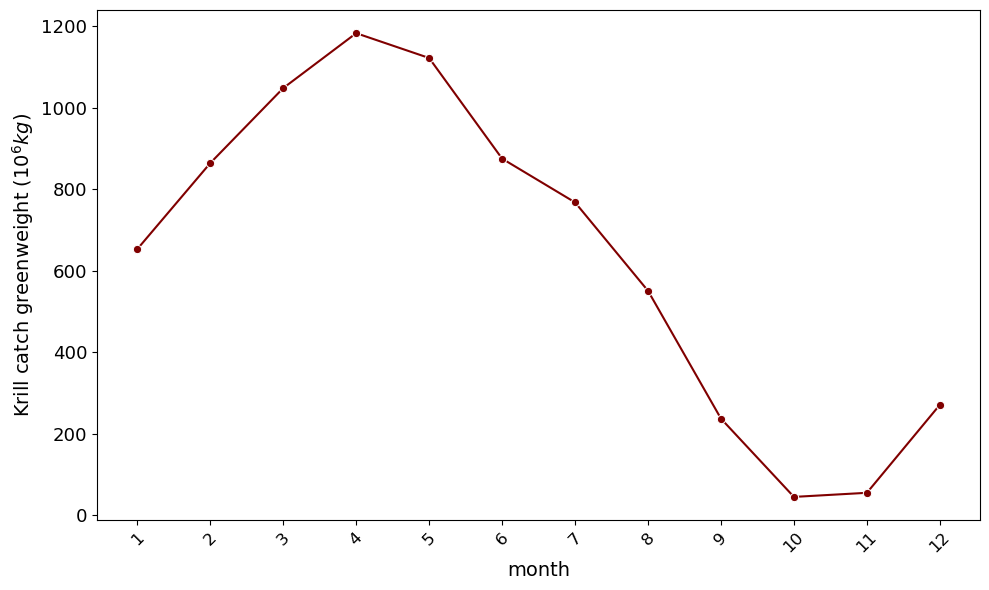

In [146]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=evo_month, x=evo_month.index, y='krill_greenweight_kg106', marker='o', color = 'maroon')


plt.xlabel("month", fontsize=14)
plt.ylabel("Krill catch greenweight ($10^6 kg$)", fontsize=14)
plt.xticks(evo_month.index, rotation=45, fontsize=12)
plt.yticks(fontsize=13)
plt.title("")
plt.tight_layout()

# plt.savefig('./figures/XXXX.png',bbox_inches='tight', dpi=300)

plt.show()

## Save this files 
File with the krill data aggrated in the grid cells. Save it to use it for further formating and exploration in the file "Krill_catch_data_formating_2"

In [137]:
# Save the dataframe as csv with all relevant data
os.chdir('C:/Users/anael/Documents/PhD/4_krill_fisheries_Carbon_seq_time/Git_repo/Key_Areas_krill_carbon_sequestration/outputs_formated_data/')
data_agg_final.to_csv('Krill_catch_aggregated.csv')
data_agg_final_summer.to_csv('Krill_catch_aggregated_summer.csv')